# Vehicle Detection, Tracking, Distance, and Occupancy Evaluation

This notebook evaluates the existing prototype without modifying its source files.

## Setup and Imports

In [1]:
from pathlib import Path
import sys
import time

import cv2
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent.parent
SRC_DIR = PROJECT_ROOT / "ai" / "vehicle_detection" / "src"
DATA_DIR = PROJECT_ROOT / "ai" / "vehicle_detection" / "data"
OUTPUT_DIR = PROJECT_ROOT / "ai" / "vehicle_detection" / "outputs"
INPUT_VIDEO = DATA_DIR / "input.mp4"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from detect import MODEL_NAME, VEHICLE_CLASSES, extract_vehicle_detections
from track import process_video as process_tracking_video
from distance import calculate_all_distances
from occupancy import PARKING_SPACES, calculate_all_occupancy, draw_parking_spaces

print(f"Project root: {PROJECT_ROOT}")
print(f"Input exists: {INPUT_VIDEO.exists()}")
print(f"Target classes: {sorted(VEHICLE_CLASSES)}")

Matplotlib is building the font cache; this may take a moment.


Project root: C:\Users\King\Aswan-SmartCurbs-AI
Input exists: True
Target classes: ['bus', 'car', 'motorcycle', 'truck']


## Input Video Information

These properties are read directly from `input.mp4`.

In [2]:
if not INPUT_VIDEO.exists():
    raise FileNotFoundError(f"Input video not found: {INPUT_VIDEO}")
capture = cv2.VideoCapture(str(INPUT_VIDEO))
if not capture.isOpened():
    raise RuntimeError(f"Could not open input video: {INPUT_VIDEO}")
video_width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
video_height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
video_fps = capture.get(cv2.CAP_PROP_FPS)
video_frame_count = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
capture.release()
video_duration = video_frame_count / video_fps if video_fps else None
print({
    "width": video_width,
    "height": video_height,
    "fps": video_fps,
    "frames": video_frame_count,
    "duration_seconds": video_duration,
})

{'width': 640, 'height': 360, 'fps': 25.0, 'frames': 750, 'duration_seconds': 30.0}


## Vehicle Detection Examples

Representative frames use the existing YOLO model and detection helper.

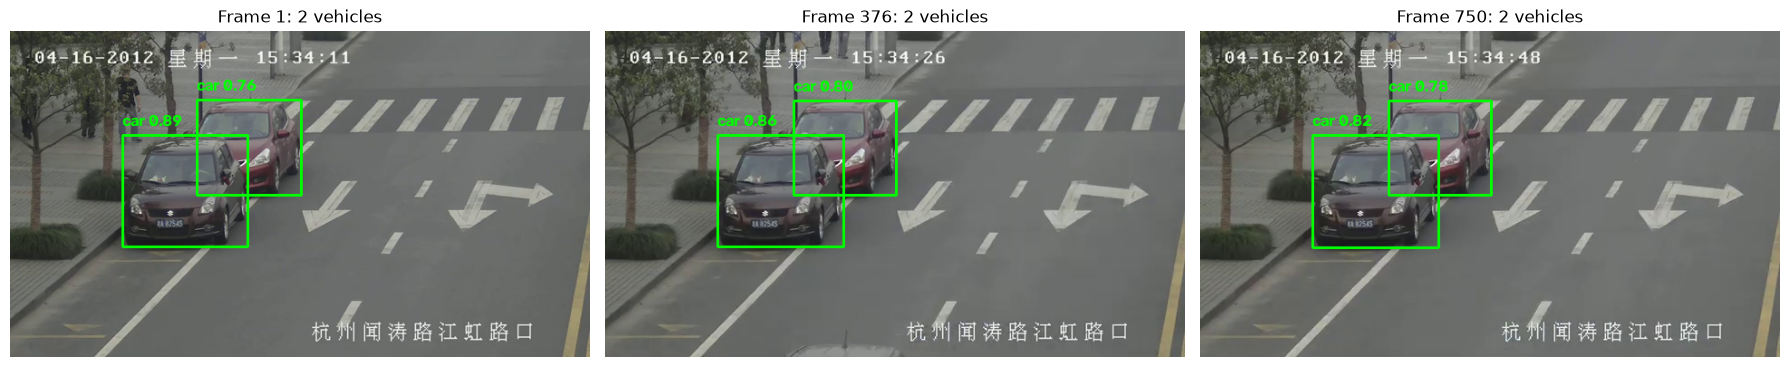

In [3]:
from ultralytics import YOLO

model = YOLO(MODEL_NAME)
example_indices = sorted({0, max(video_frame_count // 2, 0), max(video_frame_count - 1, 0)})
examples = []
capture = cv2.VideoCapture(str(INPUT_VIDEO))
for frame_index in example_indices:
    capture.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
    success, frame = capture.read()
    if not success:
        continue
    detections = extract_vehicle_detections(model(frame, verbose=False)[0], model.names)
    for detection in detections:
        x1, y1, x2, y2 = detection["x1"], detection["y1"], detection["x2"], detection["y2"]
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(frame, f'{detection["class_name"]} {detection["confidence"]:.2f}', (x1, max(y1 - 10, 20)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    examples.append((frame_index + 1, cv2.cvtColor(frame, cv2.COLOR_BGR2RGB), detections))
capture.release()

if examples:
    fig, axes = plt.subplots(1, len(examples), figsize=(18, 5))
    axes = [axes] if len(examples) == 1 else axes
    for axis, (frame_number, image, detections) in zip(axes, examples):
        axis.imshow(image)
        axis.set_title(f"Frame {frame_number}: {len(detections)} vehicles")
        axis.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No detection example frames were available.")

## Tracking Examples and FPS Measurement

The measured FPS uses the real elapsed time of the existing tracking pipeline.

In [5]:
tracking_output = OUTPUT_DIR / "vehicle_tracking_evaluation.mp4"
start_time = time.perf_counter()
all_detections = process_tracking_video(INPUT_VIDEO, tracking_output)
elapsed_seconds = time.perf_counter() - start_time
processed_frames = len(all_detections)
measured_fps = processed_frames / elapsed_seconds if elapsed_seconds > 0 else None
print(f"Processed frames: {processed_frames}")
print(f"Measured processing FPS: {measured_fps:.2f}" if measured_fps is not None else "Measured processing FPS: Not Measured")

tracking_rows = [
    {"frame_number": d["frame_number"], "track_id": d["track_id"], "class_name": d["class_name"], "confidence": d["confidence"]}
    for frame in all_detections for d in frame
]
print(*tracking_rows[:20], sep="\n")

shared_id = None
for previous, current in zip(all_detections, all_detections[1:]):
    ids = {d["track_id"] for d in previous} & {d["track_id"] for d in current}
    if ids:
        shared_id = sorted(ids)[0]
        break
print("Consecutive-frame ID association:", "Observed" if shared_id is not None else "Not observed")

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ---------------------------- ----------- 1.0/1.5 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 3.7 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

requirements: AutoUpdate success  6.1s
WARNING requirements: Restart runtime or rerun command for updates to take effect

Processed tracking video saved to: C:\Users\King\Aswan-SmartCurbs-AI\ai\vehicle_detection\outputs\vehicle_tracking_evaluation.mp4
Processed frames: 750
Measured processing FPS: 9.59
{'frame_number': 1, 'track_id': 1, 'class_name': 'car', 'confidence': 0.8885015845298767}
{'frame_number': 1, 'track_id': 2, 'class_name': 'car', 'confidence': 0.7593640685081482}
{'frame_

### Tracking Frame Previews

These frames are read from the tracking output generated by the existing pipeline.

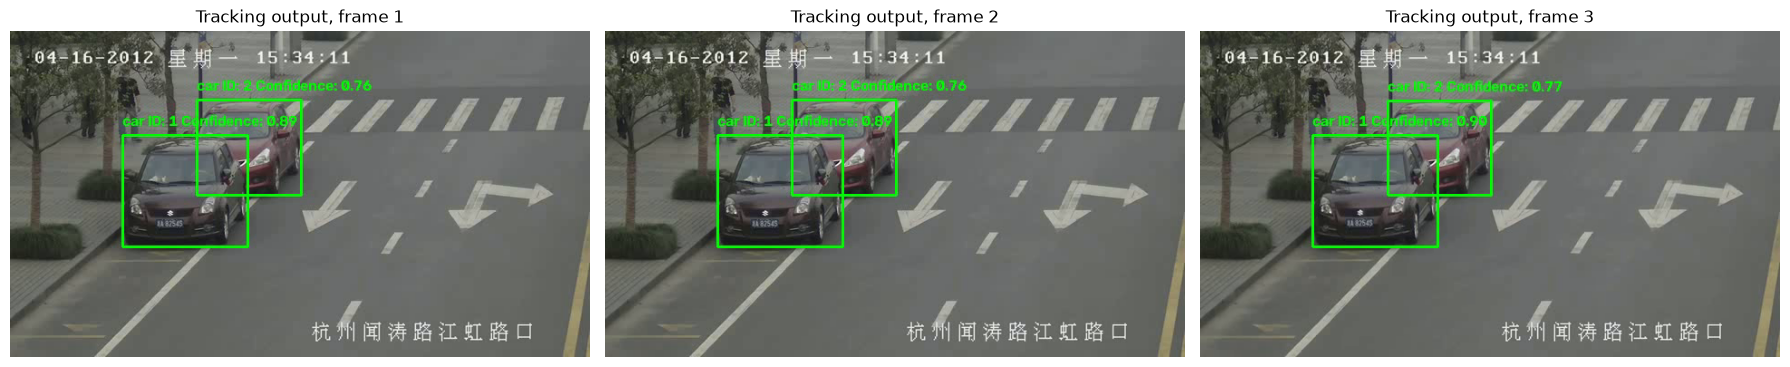

In [6]:
def read_frame(video_path, frame_index):
    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        return None
    capture.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
    success, frame = capture.read()
    capture.release()
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if success else None

nonempty_frames = [frame[0]["frame_number"] for frame in all_detections if frame]
preview_frames = []
for frame_number in nonempty_frames[:3]:
    image = read_frame(tracking_output, frame_number - 1)
    if image is not None:
        preview_frames.append((frame_number, image))
if preview_frames:
    fig, axes = plt.subplots(1, len(preview_frames), figsize=(18, 5))
    axes = [axes] if len(preview_frames) == 1 else axes
    for axis, (frame_number, image) in zip(axes, preview_frames):
        axis.imshow(image)
        axis.set_title(f"Tracking output, frame {frame_number}")
        axis.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No tracked vehicle frames were available for preview.")

## Precision, Recall, and mAP

These supervised metrics are reported only when ground-truth annotations and a valid evaluation setup exist.

In [7]:
annotation_extensions = {".txt", ".xml", ".json", ".yaml", ".yml"}
annotation_candidates = [
    path for path in PROJECT_ROOT.rglob("*")
    if path.is_file() and path.suffix.lower() in annotation_extensions
    and "__pycache__" not in path.parts
]
print("Ground-truth annotation candidates:", len(annotation_candidates))
if annotation_candidates:
    print(*[str(path.relative_to(PROJECT_ROOT)) for path in annotation_candidates[:20]], sep="\n")
else:
    print("Precision: Not Measured")
    print("Recall: Not Measured")
    print("mAP: Not Measured")
    print("Ground-truth annotations and a valid evaluation setup are required.")
precision_result = "Not Measured"
recall_result = "Not Measured"
map_result = "Not Measured"

Ground-truth annotation candidates: 606
.git\cursor\crepe\63086caa838ad4a09dc9ace56666444165976d19\metadata.json
.venv\etc\jupyter\jupyter_notebook_config.d\jupyterlab.json
.venv\etc\jupyter\jupyter_server_config.d\jupyter-lsp-jupyter-server.json
.venv\etc\jupyter\jupyter_server_config.d\jupyterlab.json
.venv\etc\jupyter\jupyter_server_config.d\jupyter_server_terminals.json
.venv\etc\jupyter\jupyter_server_config.d\notebook.json
.venv\etc\jupyter\jupyter_server_config.d\notebook_shim.json
.venv\etc\jupyter\nbconfig\notebook.d\widgetsnbextension.json
.venv\Lib\site-packages\anyio-4.14.2.dist-info\entry_points.txt
.venv\Lib\site-packages\anyio-4.14.2.dist-info\scm_file_list.json
.venv\Lib\site-packages\anyio-4.14.2.dist-info\scm_version.json
.venv\Lib\site-packages\anyio-4.14.2.dist-info\top_level.txt
.venv\Lib\site-packages\asttokens-3.0.2.dist-info\scm_file_list.json
.venv\Lib\site-packages\asttokens-3.0.2.dist-info\scm_version.json
.venv\Lib\site-packages\asttokens-3.0.2.dist-info\top

## Distance Examples

Distances use the existing `distance.py` implementation and tracked centers. They are image-space pixel measurements, not meters.

In [8]:
all_distance_results = calculate_all_distances(all_detections)
distance_examples = [
    (result["frame_number"], distance)
    for result in all_distance_results for distance in result["distances"]
]
if distance_examples:
    for frame_number, distance in distance_examples[:10]:
        print(f"Frame {frame_number}")
        print(f"Vehicle ID {distance['vehicle_1_id']} <-> Vehicle ID {distance['vehicle_2_id']}")
        print(f"Distance = {distance['distance_pixels']:.2f} pixels")
else:
    print("No frame contained two tracked vehicles, so no distance was calculated.")
print("The distance is measured in pixels in image space.")
print("Real-world distance requires camera calibration, a known reference distance, or perspective transformation.")

Frame 1
Vehicle ID 1 <-> Vehicle ID 2
Distance = 85.29 pixels
Frame 2
Vehicle ID 1 <-> Vehicle ID 2
Distance = 85.29 pixels
Frame 3
Vehicle ID 1 <-> Vehicle ID 2
Distance = 85.42 pixels
Frame 4
Vehicle ID 1 <-> Vehicle ID 2
Distance = 85.29 pixels
Frame 5
Vehicle ID 1 <-> Vehicle ID 2
Distance = 85.42 pixels
Frame 6
Vehicle ID 1 <-> Vehicle ID 2
Distance = 85.42 pixels
Frame 7
Vehicle ID 1 <-> Vehicle ID 2
Distance = 85.70 pixels
Frame 8
Vehicle ID 1 <-> Vehicle ID 2
Distance = 85.70 pixels
Frame 9
Vehicle ID 1 <-> Vehicle ID 2
Distance = 85.70 pixels
Frame 10
Vehicle ID 1 <-> Vehicle ID 2
Distance = 85.70 pixels
The distance is measured in pixels in image space.
Real-world distance requires camera calibration, a known reference distance, or perspective transformation.


## Parking Occupancy Evaluation

Occupancy uses the configured five polygons and actual vehicle center positions from the tracking output.

Frame 1
Space 1: Free
Space 2: Free
Space 3: Free
Space 4: Occupied
Vehicle ID: 1
Space 5: Occupied
Vehicle ID: 2
Frame 2
Space 1: Free
Space 2: Free
Space 3: Free
Space 4: Occupied
Vehicle ID: 1
Space 5: Occupied
Vehicle ID: 2
Frame 3
Space 1: Free
Space 2: Free
Space 3: Free
Space 4: Occupied
Vehicle ID: 1
Space 5: Occupied
Vehicle ID: 2
Frame 4
Space 1: Free
Space 2: Free
Space 3: Free
Space 4: Occupied
Vehicle ID: 1
Space 5: Occupied
Vehicle ID: 2
Frame 5
Space 1: Free
Space 2: Free
Space 3: Free
Space 4: Occupied
Vehicle ID: 1
Space 5: Occupied
Vehicle ID: 2
Frame 6
Space 1: Free
Space 2: Free
Space 3: Free
Space 4: Occupied
Vehicle ID: 1
Space 5: Occupied
Vehicle ID: 2
Frame 7
Space 1: Free
Space 2: Free
Space 3: Free
Space 4: Occupied
Vehicle ID: 1
Space 5: Occupied
Vehicle ID: 2
Frame 8
Space 1: Free
Space 2: Free
Space 3: Free
Space 4: Occupied
Vehicle ID: 1
Space 5: Occupied
Vehicle ID: 2
Frame 9
Space 1: Free
Space 2: Free
Space 3: Free
Space 4: Occupied
Vehicle ID: 1
Space 

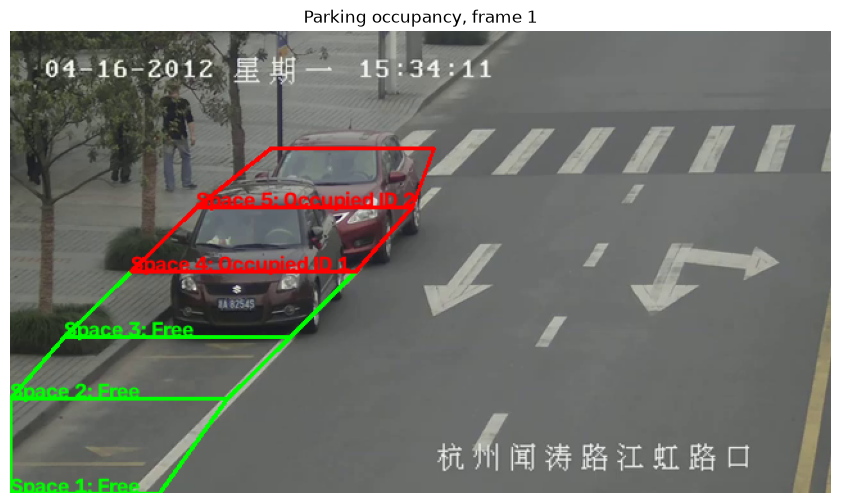

In [9]:
occupancy_results = calculate_all_occupancy(all_detections, PARKING_SPACES)
for frame_result in occupancy_results[:10]:
    print(f"Frame {frame_result['frame_number']}")
    for space_id, result in frame_result["spaces"].items():
        print(f"Space {space_id}: {result['status']}")
        if result["vehicle_id"] is not None:
            print(f"Vehicle ID: {result['vehicle_id']}")

# Show the configured polygons and calculated statuses on the first available frame.
capture = cv2.VideoCapture(str(INPUT_VIDEO))
success, frame = capture.read()
capture.release()
if success and occupancy_results:
    annotated = draw_parking_spaces(frame.copy(), PARKING_SPACES, occupancy_results[0]["spaces"])
    plt.figure(figsize=(12, 6))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Parking occupancy, frame {occupancy_results[0]['frame_number']}")
    plt.show()

## Summary

Only measured or genuinely available results are reported.

In [10]:
summary = [
    ("Vehicle Detection", "Measured/Available"),
    ("Tracking", "Available"),
    ("FPS", f"{measured_fps:.2f}" if measured_fps is not None else "Not Measured"),
    ("Precision", precision_result),
    ("Recall", recall_result),
    ("mAP", map_result),
    ("Pixel Distance", "Available" if distance_examples else "Not Measured"),
    ("Real-World Distance", "Not Implemented"),
    ("Parking Occupancy", "Available" if occupancy_results is not None else "Not Measured"),
]
print("Metric | Result")
print("--- | ---")
for metric, result in summary:
    print(f"{metric} | {result}")

Metric | Result
--- | ---
Vehicle Detection | Measured/Available
Tracking | Available
FPS | 9.59
Precision | Not Measured
Recall | Not Measured
mAP | Not Measured
Pixel Distance | Available
Real-World Distance | Not Implemented
Parking Occupancy | Available
